<a href="https://colab.research.google.com/github/AmitabhDey-byte/Project3/blob/main/gdg_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

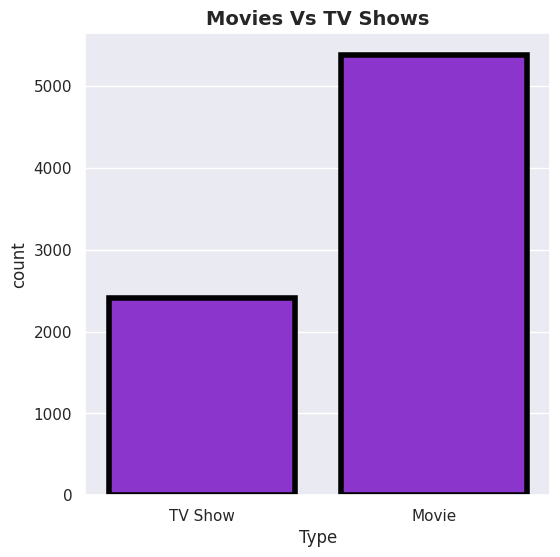

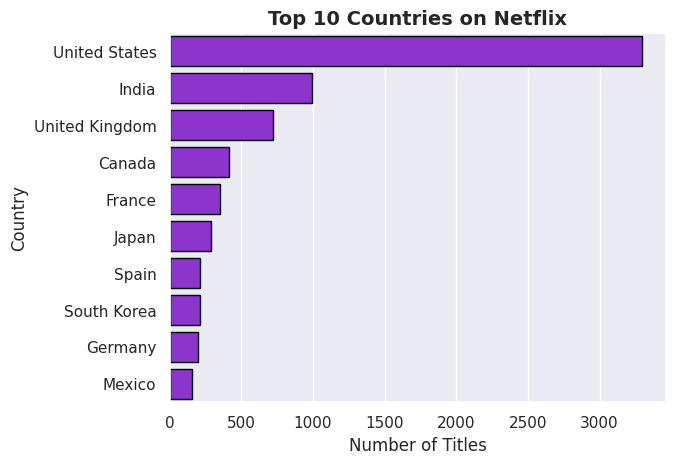

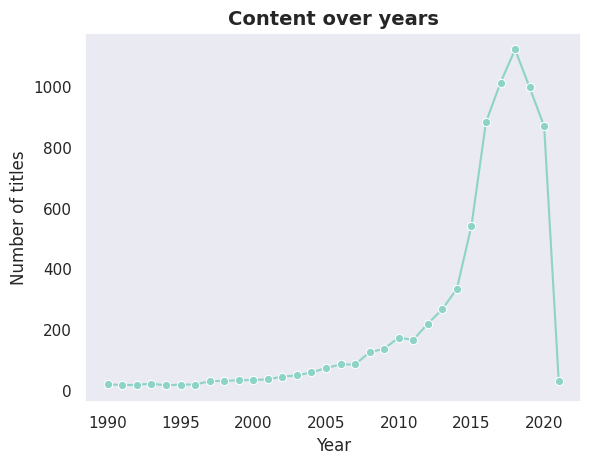

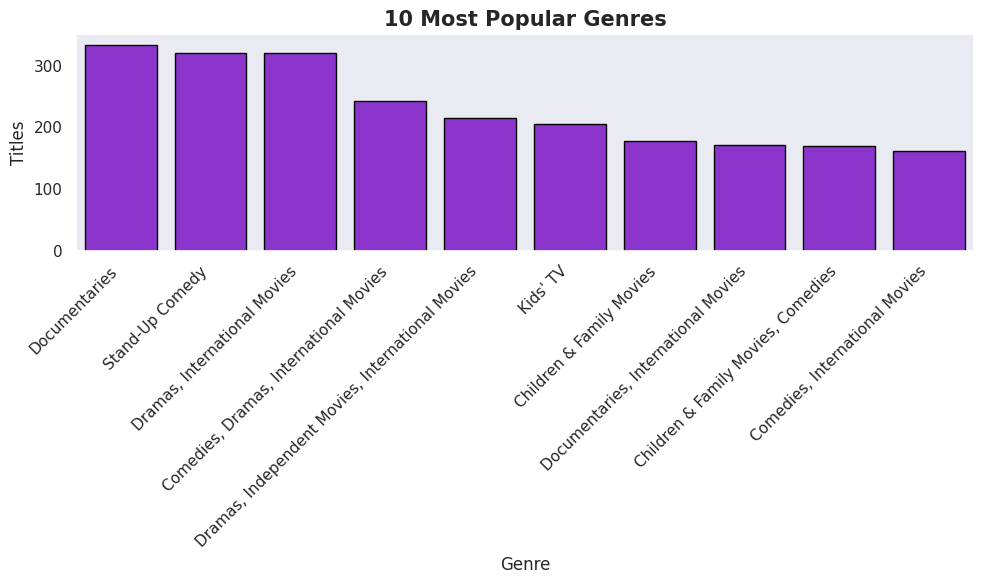

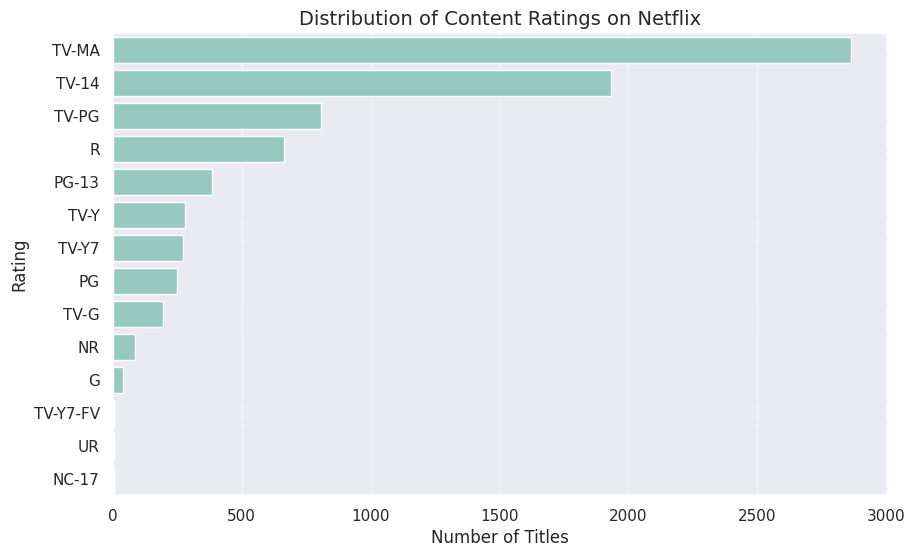

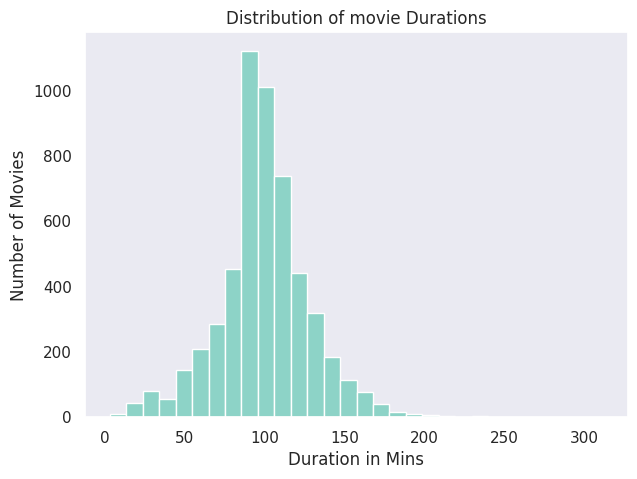

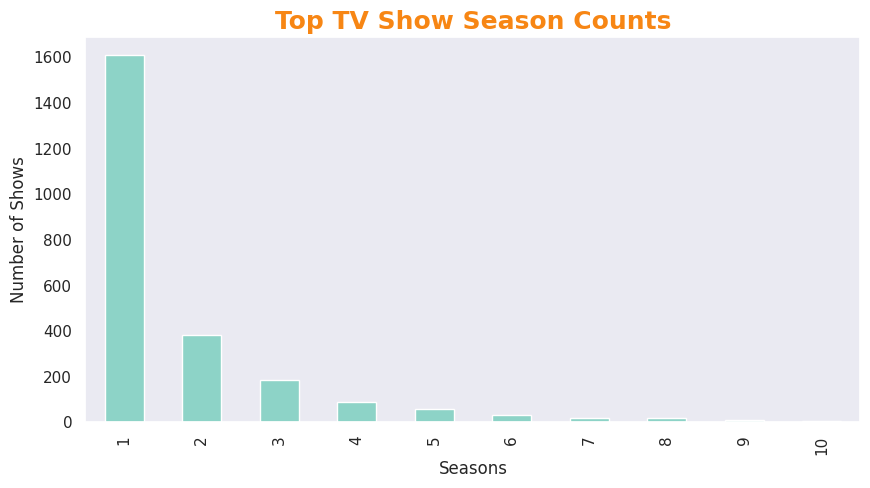

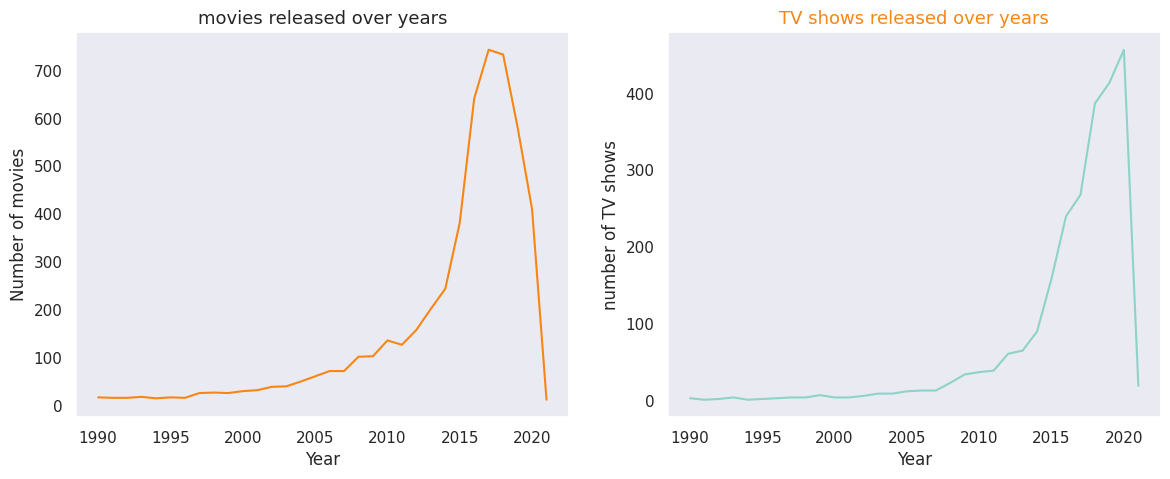

In [27]:
import numpy as np
import seaborn as sea
import pandas as pd
import matplotlib.pyplot as plt

sea.set_theme(style="darkgrid", palette="Set3")

ingest = pd.read_csv("/content/sample_data/NetFlix.csv")

df = ingest.loc[:, ~ingest.columns.str.contains('^Unnamed')]

#fist visualiztion (Movie and TV Shows)
plt.figure(figsize=(6,6))
sea.countplot(x='type', data=df, linewidth=4, color='#8e1ce6',edgecolor='black')

plt.title("Movies Vs TV Shows", fontsize=14, weight='bold')
plt.xlabel("Type")
plt.ylabel("count")
plt.show()

#2nd Visualization Content by Country -- konse country ka kitna content
country_counting = df['country'].str.split(', ').explode().value_counts().head(10)


sea.barplot(x=country_counting.values, y=country_counting.index,color='#8e1ce6',edgecolor='black')
sea.set_style("dark")
plt.title("Top 10 Countries on Netflix", fontsize=14, weight='bold')
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

#3rd Visualizition :content over years

year_counting = df['release_year'].value_counts().sort_index()
years = np.arange(1990, year_counting.index.max() + 1)

year_counting = year_counting.reindex(years, fill_value=0)

sea.lineplot(x=year_counting.index, y=year_counting.values, marker= 'o')
plt.title("Content over years", fontsize=14, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of titles")
plt.show()

#4th Visualization : Most popular genres-- categories

genre_counting = df [ 'genres'].value_counts().head(10)

plt.figure(figsize=(10,6))
sea.barplot(x=genre_counting.index, y=genre_counting.values,color='#8e1ce6',edgecolor='black')
plt.title("10 Most Popular Genres", fontsize=15, weight='bold')
plt.xlabel("Genre")
plt.ylabel("Titles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#5th Visualization :Rating Distribution-- like ADULT oriented h ya cool for everyon

plt.figure(figsize=(10,6))
sea.countplot(y='rating',data=df,order=df['rating'].value_counts().index)

plt.title("Distribution of Content Ratings on Netflix", fontsize=14, )
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

#6th Visualization: Movie Durations

movies = df[df['type'] == 'Movie'].copy()

plt.figure(figsize=(7,5))
plt.hist(movies['duration'], bins=30)

plt.title("Distribution of movie Durations")
plt.xlabel("Duration in Mins")
plt.ylabel("Number of Movies")

plt.show()

#7th Visualization: no os seasons in tv shows

tv = df[df['type'] == 'TV Show'].copy()

plt.figure(figsize=(10,5))
tv['duration'].value_counts().head(10).plot(kind='bar')

plt.title("Top TV Show Season Counts",fontsize=18, weight='bold', color='#f78614' )
plt.xlabel("Seasons")
plt.ylabel("Number of Shows")

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

movie_year = df[df['type']=='Movie']['release_year'].value_counts().sort_index()
tv_year = df[df['type']=='TV Show']['release_year'].value_counts().sort_index()

years = np.arange(1990, max(movie_year.index.max(), tv_year.index.max()) + 1)

movie_year = movie_year.reindex(years, fill_value=0)
tv_year = tv_year.reindex(years, fill_value=0)

sea.lineplot(x=movie_year.index, y=movie_year.values, ax=axes[0], color='#f78614')
axes[0].set_title("movies released over years", fontsize=13)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of movies")

sea.lineplot(x=tv_year.index, y=tv_year.values, ax=axes[1])
axes[1].set_title("TV shows released over years", fontsize=13, color='#f78614')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("number of TV shows")


plt.show()